In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
data = pd.read_csv("framingham.csv")

In [3]:
data.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
data.shape

(4238, 16)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [6]:
data.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4133.000000,4238.000000,4209.000000,4185.000000,4238.000000,4238.000000,4238.000000,4188.000000,4238.000000,4238.000000,4219.000000,4237.000000,3850.000000,4238.000000
mean,0.429212,49.584946,1.978950,0.494101,9.003089,0.029630,0.005899,0.310524,0.025720,236.721585,132.352407,82.893464,25.802008,75.878924,81.966753,0.151958
std,0.495022,8.572160,1.019791,0.500024,11.920094,0.169584,0.076587,0.462763,0.158316,44.590334,22.038097,11.910850,4.080111,12.026596,23.959998,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.070000,68.000000,71.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,263.000000,144.000000,89.875000,28.040000,83.000000,87.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


data.isnull().sum()

In [8]:
data.duplicated().sum()

np.int64(0)

for better understanding of a column header here converting in to lower_case and replacing with underscore

In [10]:
data.columns = data.columns.str.lower()

In [14]:
data.columns = data.columns.str.replace(" ","_")

In [15]:
data.columns = data.columns.str.strip()

In [16]:
data.head()

,male,age,education,currentsmoker,cigsperday,bpmeds,prevalentstroke,prevalenthyp,diabetes,totchol,sysbp,diabp,bmi,heartrate,glucose,tenyearchd
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [19]:
from sklearn.impute import SimpleImputer
cols = {
        "education","cigsperday","bpmeds","totchol","bmi",
        "heartrate", "glucose"
       }
si = SimpleImputer(missing_values = np.nan,strategy = "mean")
for col in cols:
    data[col] = si.fit_transform(data[[col]])

In [22]:
print("After Applying the Simple Imputer:")
data.isnull().sum()

After Applying the Simple Imputer:


male               0
age                0
education          0
currentsmoker      0
cigsperday         0
bpmeds             0
prevalentstroke    0
prevalenthyp       0
diabetes           0
totchol            0
sysbp              0
diabp              0
bmi                0
heartrate          0
glucose            0
tenyearchd         0
dtype: int64

In [24]:
data["tenyearchd"].value_counts()

tenyearchd
0    3594
1     644
Name: count, dtype: int64

In [25]:
data["tenyearchd"].value_counts(normalize=True)

tenyearchd
0    0.848042
1    0.151958
Name: proportion, dtype: float64

EDA Processing 

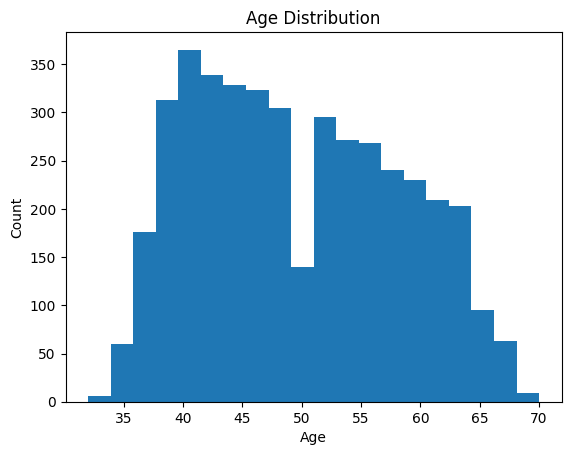

In [37]:
#plt.figure(figsize = (10,8))
plt.hist(x = data["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")
plt.show()

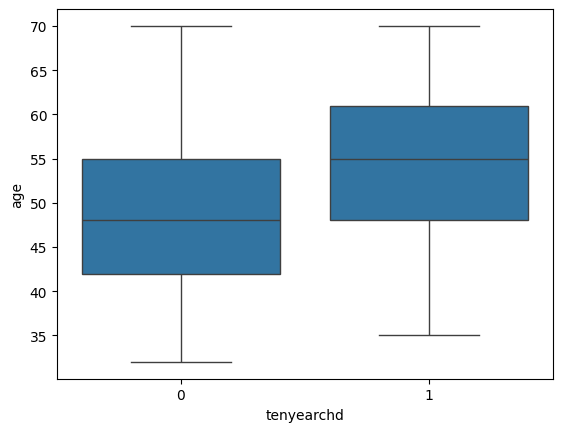

In [38]:
sns.boxplot(x="tenyearchd", y="age", data=data)
plt.show()


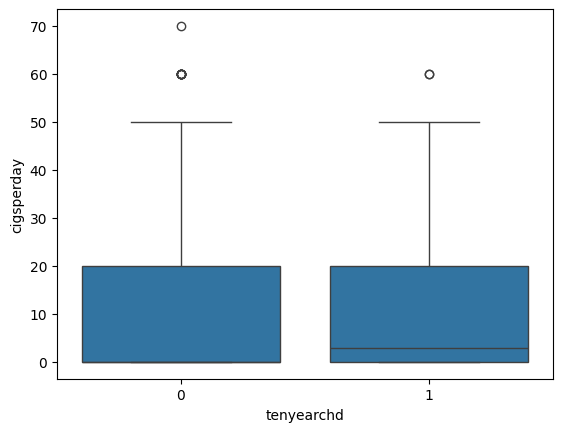

In [39]:
sns.boxplot(x="tenyearchd", y="cigsperday", data=data)
plt.show()


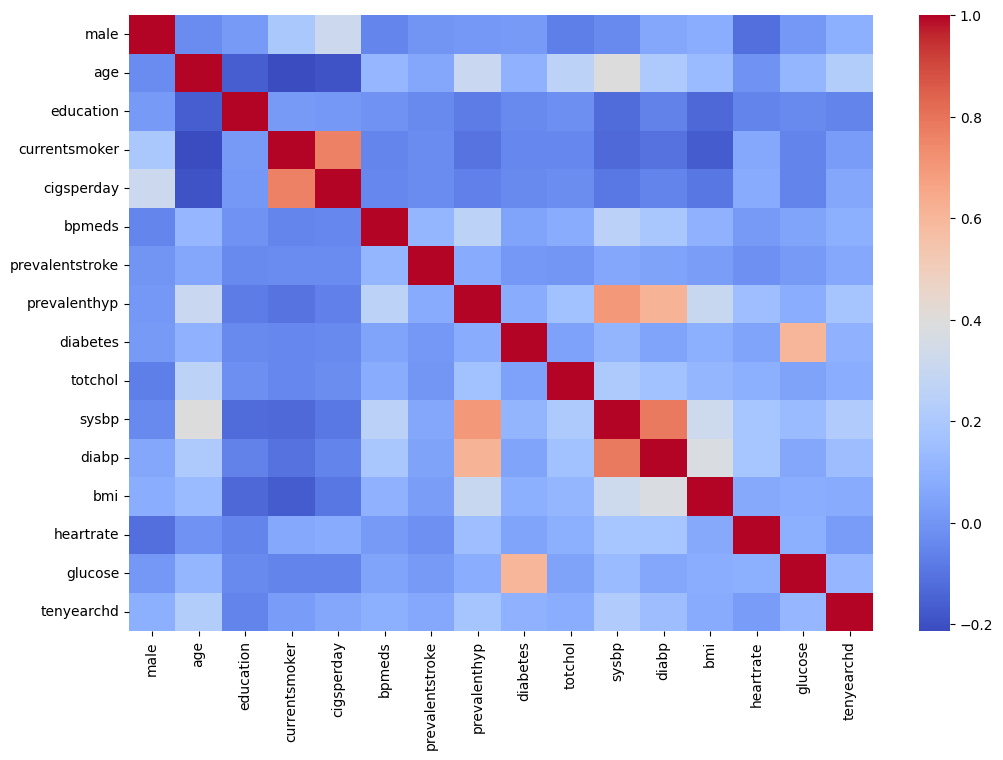

In [40]:
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), cmap="coolwarm", annot=False)
plt.show()

In [45]:
x = data.drop("tenyearchd", axis=1)
y = data["tenyearchd"]

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [59]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,test_size = 0.25,random_state = 42)

In [60]:
scaler = StandardScaler()
xtrain_scaler = scaler.fit_transform(xtrain)
xtest_scaler = scaler.fit_transform(xtest)

In [61]:
model = LogisticRegression()
model.fit(xtrain_scaler,ytrain)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [62]:
ypred = model.predict(xtrain_scaler)

In [63]:
ypred

array([0, 0, 0, ..., 0, 0, 0], shape=(3178,))

In [64]:
xtrain_scaler.shape

(3178, 15)

In [65]:
y_pred_proba = model.predict_proba(xtest_scaler)[:, 1]

In [54]:
y_pred_proba

array([0.32792679, 0.07540941, 0.0922057 , 0.16654406, 0.05956594,
       0.18231847, 0.06633529, 0.18080207, 0.17428373, 0.46505776,
       0.24969021, 0.24151097, 0.04287059, 0.12514396, 0.22442914,
       0.07275139, 0.26861221, 0.13019489, 0.29713603, 0.25558543,
       0.38744434, 0.03435808, 0.06971187, 0.02335825, 0.15521933,
       0.15638271, 0.07162338, 0.11922519, 0.11739334, 0.06218707,
       0.34527559, 0.09445123, 0.08496527, 0.07627113, 0.05679606,
       0.03481269, 0.09462093, 0.03669373, 0.13101406, 0.07594266,
       0.31486815, 0.11295837, 0.16697956, 0.17554993, 0.04739438,
       0.04355548, 0.18470055, 0.03498861, 0.08899373, 0.23769931,
       0.03949519, 0.38880278, 0.21540689, 0.115982  , 0.03708861,
       0.0883732 , 0.32558654, 0.11803652, 0.04324275, 0.03097714,
       0.10165155, 0.10816733, 0.19545713, 0.04136231, 0.16010813,
       0.0334625 , 0.23720879, 0.14212904, 0.14687801, 0.1233509 ,
       0.11300198, 0.04184039, 0.08719478, 0.21151543, 0.06519

In [71]:
ypred = model.predict(xtest)
accuracy_score(ytest, ypred)

C:\Users\Sriharshini\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


0.14339622641509434

In [73]:
recall = recall_score(ytest, ypred)
print(recall)

1.0


In [74]:
roc = roc_auc_score(ytest, ypred)
print(roc)

0.5


In [75]:
con_mat = confusion_matrix(ytest,ypred)
print(con_mat)

[[  0 908]
 [  0 152]]


ROC CURVE

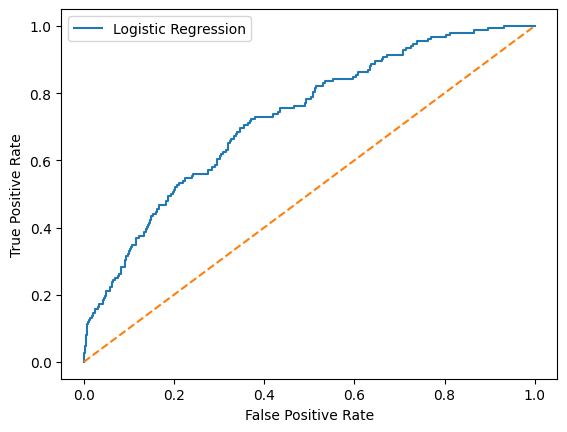

In [76]:
fpr, tpr, _ = roc_curve(ytest, y_pred_proba)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [77]:
import numpy as np

# Choose feature index (example: age)
feature_name = "age"
feature_index = X.columns.get_loc(feature_name)

# Create age range
age_range = np.linspace(
    X[feature_name].min(),
    X[feature_name].max(),
    300
)


In [78]:
# Create input matrix
X_mean = np.mean(xtrain_scaler, axis=0)

X_plot = np.tile(X_mean, (len(age_range), 1))
X_plot[:, feature_index] = (
    age_range - X[feature_name].mean()
) / X[feature_name].std()


In [79]:
y_prob = model.predict_proba(X_plot)[:, 1]


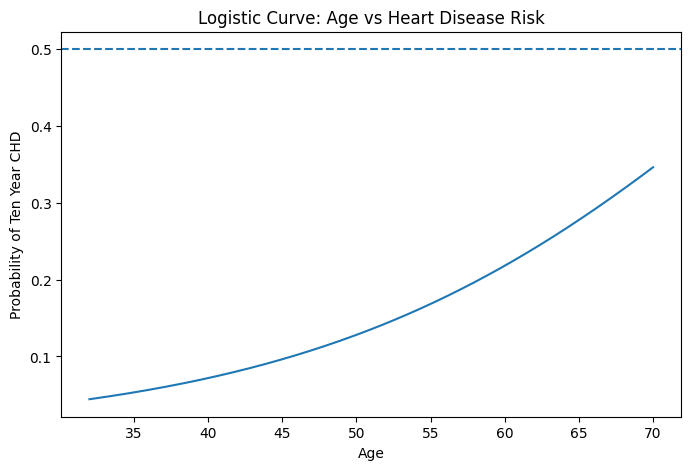

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(age_range, y_prob)
plt.axhline(0.5, linestyle="--")
plt.xlabel("Age")
plt.ylabel("Probability of Ten Year CHD")
plt.title("Logistic Curve: Age vs Heart Disease Risk")
plt.show()
